# Import packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

In [2]:
train_df = pd.read_csv('../input/competitions/titanic/train.csv')
test_df = pd.read_csv('../input/competitions/titanic/test.csv')

In [3]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.shape

(891, 12)

# Data Preprocessing

In [5]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [7]:
train_df.info()
print('-'*40)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

In [8]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
train_df['Age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64

In [11]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

In [12]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [14]:
train_df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [15]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [16]:
train_df = train_df.drop(['Cabin', 'Name', 'Ticket'], axis=1)

In [17]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df = train_df.drop(['SibSp', 'Parch'], axis=1)

In [18]:
train_df.head(5)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,1,0,3,male,22.0,7.2500,S,2
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,1


In [19]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# Data Visualization

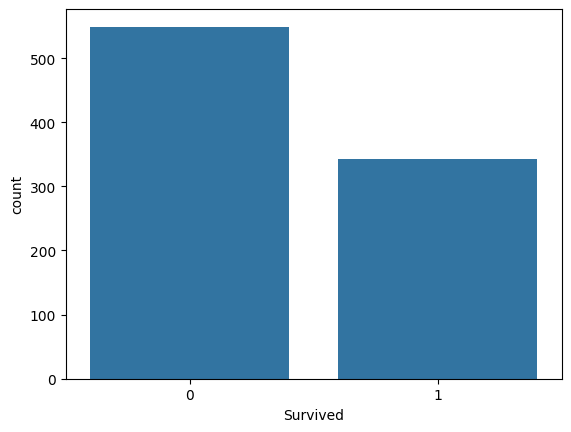

In [20]:
sns.countplot(train_df, x='Survived')
plt.show()

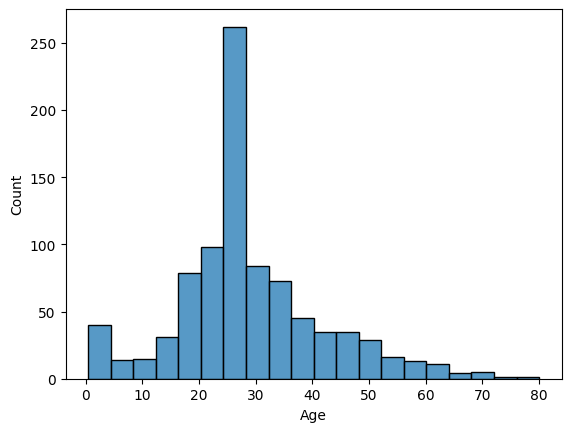

In [21]:
sns.histplot(train_df, x='Age', bins=20)
plt.show()

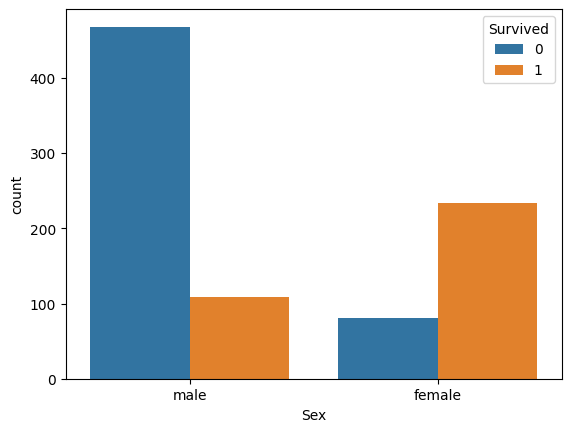

In [22]:
sns.countplot(train_df, x='Sex', hue='Survived')
plt.show()

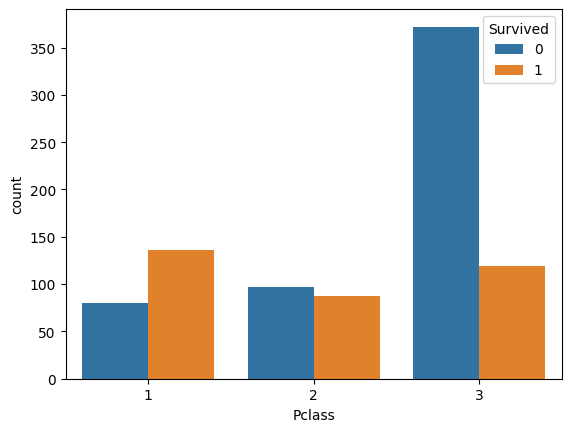

In [23]:
sns.countplot(train_df, x='Pclass', hue='Survived')
plt.show()

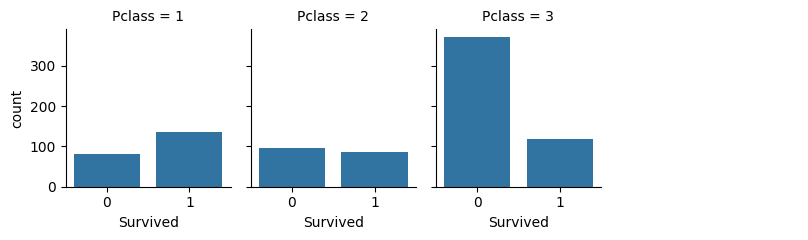

In [24]:
sns.catplot(x='Survived',col='Pclass',col_wrap=4, data =train_df ,
            kind='count',height=2.5,aspect=.8)

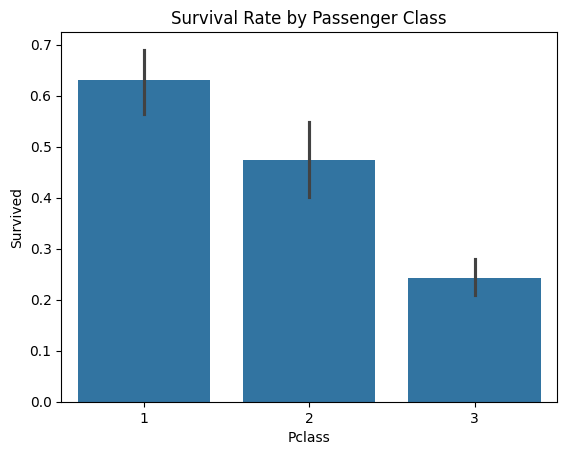

In [25]:
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title("Survival Rate by Passenger Class")
plt.show()

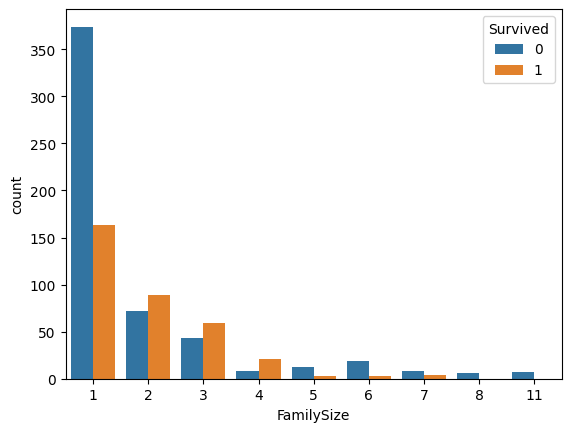

In [26]:
sns.countplot(train_df, x='FamilySize', hue='Survived')
plt.show()

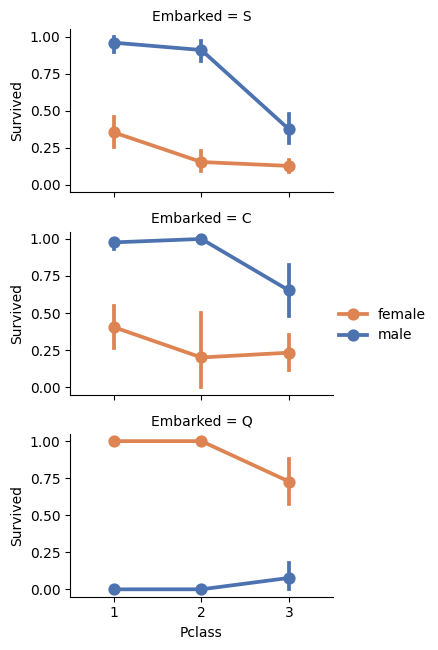

In [27]:
plot = sns.FacetGrid(train_df, row='Embarked', height=2.2, aspect=1.6)

plot.map_dataframe(
    sns.pointplot,
    x='Pclass',
    y='Survived',
    hue='Sex',
    palette='deep'
)

plot.add_legend()
plt.show()

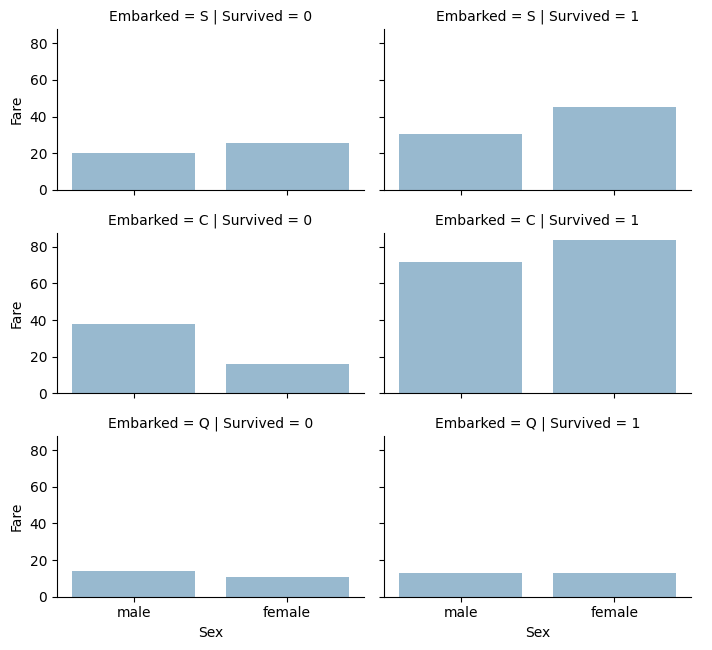

In [28]:
plot = sns.FacetGrid(train_df, row='Embarked', col='Survived', height=2.2, aspect=1.6)

plot.map_dataframe(
    sns.barplot,
    x='Sex',
    y='Fare',
    alpha=0.5,
    errorbar=None
)

plot.add_legend()
plt.show()

In [29]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 20, 40, 60, 100], 
                             labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])

In [30]:
train_df = train_df.drop('Age', axis=1)

In [31]:
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df = pd.get_dummies(train_df, columns=['Embarked', 'AgeGroup'])

In [32]:
bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)

In [33]:
train_df['FareGroup'] = pd.qcut(train_df['Fare'], 4, labels=False)
train_df = train_df.drop('Fare', axis=1)

In [34]:
train_df.head(5)

,PassengerId,Survived,Pclass,Sex,FamilySize,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_MidAge,AgeGroup_Senior,FareGroup
0,1,0,3,0,2,0,0,1,0,0,1,0,0,0
1,2,1,1,1,2,1,0,0,0,0,1,0,0,3
2,3,1,3,1,1,0,0,1,0,0,1,0,0,1
3,4,1,1,1,2,0,0,1,0,0,1,0,0,3
4,5,0,3,0,1,0,0,1,0,0,1,0,0,1


# Correlation coefficient

In [35]:
corr = train_df.corr()['Survived'].sort_values(ascending=False)
print(f'Correlation:\n{corr}')

Correlation:
Survived           1.000000
Sex                0.543351
FareGroup          0.299357
Embarked_C         0.168240
AgeGroup_Child     0.116691
FamilySize         0.016639
AgeGroup_MidAge    0.005716
Embarked_Q         0.003650
AgeGroup_Teen     -0.001559
PassengerId       -0.005007
AgeGroup_Senior   -0.051224
AgeGroup_Adult    -0.051250
Embarked_S        -0.149683
Pclass            -0.338481
Name: Survived, dtype: float64


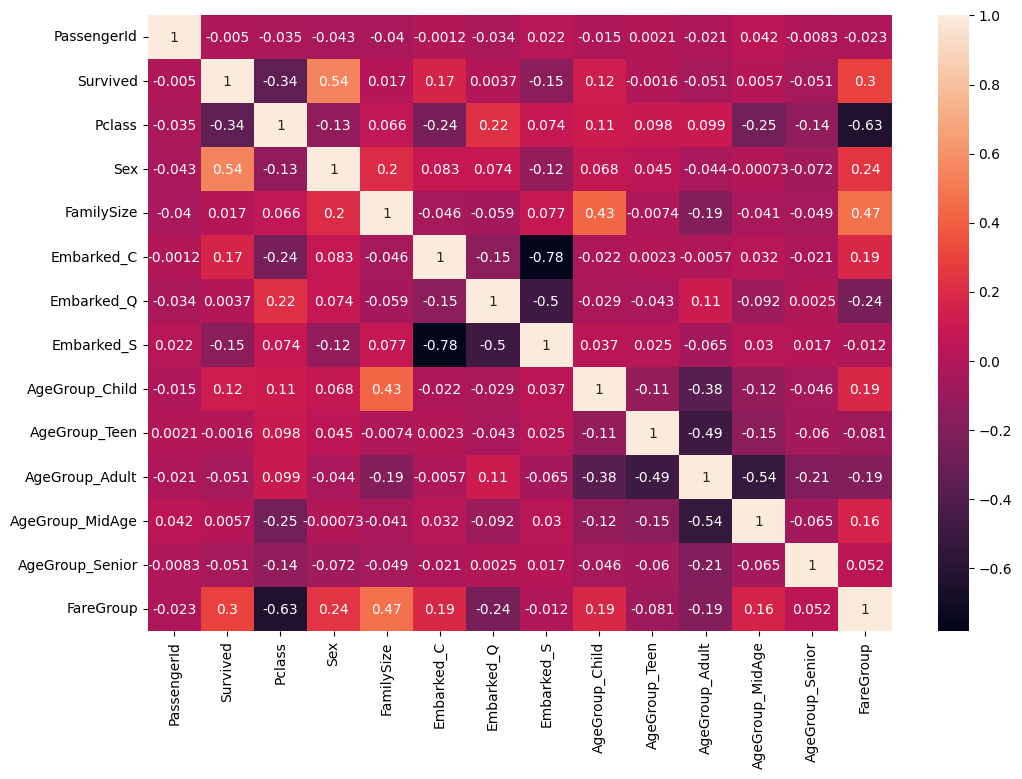

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(), annot=True)
plt.show()

# Test_df

In [37]:
test_df.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [38]:
test_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Peter, Master. Michael J",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292
Cabin,91,76,B57 B59 B63 B66,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [40]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [41]:
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

In [42]:
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [43]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

In [44]:
test_df = test_df.drop(['Cabin', 'Name', 'Ticket'], axis=1)

In [45]:
test_df['AgeGroup'] = pd.cut(test_df['Age'], bins=[0, 12, 20, 40, 60, 100], 
                             labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])

In [46]:
test_df = test_df.drop('Age', axis=1)

In [47]:
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df = test_df.drop(['SibSp', 'Parch'], axis=1)

In [48]:
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df = pd.get_dummies(test_df, columns=['Embarked', 'AgeGroup'])

In [49]:
bool_cols = test_df.select_dtypes(include='bool').columns
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [50]:
test_df['FareGroup'] = pd.qcut(test_df['Fare'], 4, labels=False)
test_df = test_df.drop('Fare', axis=1)

In [51]:
test_df.head(5)

,PassengerId,Pclass,Sex,FamilySize,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_MidAge,AgeGroup_Senior,FareGroup
0,892,3,0,1,0,1,0,0,0,1,0,0,0
1,893,3,1,2,0,0,1,0,0,0,1,0,0
2,894,2,0,1,0,1,0,0,0,0,0,1,1
3,895,3,0,1,0,0,1,0,0,1,0,0,1
4,896,3,1,3,0,0,1,0,0,1,0,0,1


In [52]:
X_train = train_df.drop(['PassengerId', 'Survived'], axis=1)
y_train = train_df['Survived']
X_test = test_df.drop('PassengerId', axis=1)

In [53]:
X_train.shape, y_train.shape, X_test.shape

((891, 12), (891,), (418, 12))

# ML Models

# Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [56]:
acc_log_reg = round(log_reg.score(X_train, y_train)*100, 2)
acc_log_reg

79.8

In [57]:
y_pred_log = log_reg.predict(X_test)

# Support Vector Machine

In [58]:
from sklearn.svm import SVC

In [59]:
svc = SVC(kernel='rbf', gamma=1)
svc.fit(X_train, y_train)

SVC(gamma=1)

In [60]:
acc_svc = round(svc.score(X_train, y_train)*100, 2)
acc_svc

87.32

In [61]:
y_pred_svc = svc.predict(X_test)

# Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [64]:
acc_dt = round(dt.score(X_train, y_train)*100, 2)
acc_dt

87.21

In [65]:
y_pred_dt = dt.predict(X_test)

# KNN

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [68]:
acc_knn = round(knn.score(X_train, y_train)*100, 2)
acc_knn

86.53

In [69]:
y_pred_knn = knn.predict(X_test)

# Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [72]:
acc_rf = round(rf.score(X_train, y_train)*100, 2)
acc_rf

87.43

In [73]:
y_pred_rf = rf.predict(X_test)

# Naive Bayes

In [74]:
from sklearn.naive_bayes import GaussianNB

In [75]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [76]:
acc_nb = round(nb.score(X_train, y_train)*100, 2)
acc_nb

78.23

In [77]:
y_pred_nb = nb.predict(X_test)

# Gradient Boosting

In [78]:
from sklearn.ensemble import GradientBoostingClassifier

In [79]:
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [80]:
acc_gb = round(gb.score(X_train, y_train)*100, 2)
acc_gb

85.3

In [81]:
y_pred_gb = gb.predict(X_test)

# AdaBoost

In [82]:
from sklearn.ensemble import AdaBoostClassifier

In [83]:
ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [84]:
acc_ada = round(ada.score(X_train, y_train)*100, 2)
acc_ada

81.37

In [85]:
y_pred_ada = ada.predict(X_test)

In [86]:
models = pd.DataFrame({
    'Model':['KNN', 'AdaBoost', 'Naive Bayes', 'Support Vector Machine', 'Gradient Bossting', 
             'Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Score':[acc_knn, acc_ada, acc_nb, acc_svc, acc_gb, acc_log_reg, acc_dt, acc_rf]
}).sort_values(by='Score', ascending=False)

In [87]:
models

,Model,Score
7,Random Forest,87.43
3,Support Vector Machine,87.32
6,Decision Tree,87.21
0,KNN,86.53
4,Gradient Bossting,85.30
1,AdaBoost,81.37
5,Logistic Regression,79.80
2,Naive Bayes,78.23


# Random Forest is the best model 

In [88]:
submission = pd.DataFrame({
    'PassengerId':test_df['PassengerId'],
    'Survived':y_pred_rf
})

In [89]:
submission.head(5)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [90]:
submission.to_csv('submission.csv', index=False)